# 03 — Exploratory Data Analysis

Systematic exploration of the cleaned Olist dataset across five analytical dimensions:

1. **Revenue & Volume Trends** — how money and orders flow over time
2. **Customer Geography** — where demand and revenue concentrate
3. **Product Category Performance** — which categories drive (or drain) the business
4. **Delivery & Satisfaction** — how logistics quality maps to customer happiness
5. **Payment Behaviour & Pricing** — how customers pay and how pricing affects outcomes

Every chart is followed by a **business insight** written in decision language — not just what the data shows, but what Olist should *do* about it.

---
## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_olist_dataset.csv"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv(DATA_PATH, parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "shipping_limit_date",
    "review_creation_date", "review_answer_timestamp",
])

print(f"Dataset: {len(df):,} rows × {df.columns.size} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")

Dataset: 110,197 rows × 48 columns
Date range: 2016-09-15 → 2018-08-29


In [2]:
# Order-level dataframe (one row per order) — used for metrics that shouldn't be inflated by multi-item orders
order_level = df.groupby("order_id").agg(
    customer_unique_id=("customer_unique_id", "first"),
    customer_state=("customer_state", "first"),
    customer_city=("customer_city", "first"),
    purchase_timestamp=("order_purchase_timestamp", "first"),
    purchase_month=("purchase_month", "first"),
    total_payment=("total_payment_value", "first"),
    review_score=("review_score", "first"),
    delivery_delay_days=("delivery_delay_days", "first"),
    is_on_time=("is_on_time", "first"),
    actual_delivery_days=("actual_delivery_days", "first"),
    primary_payment_type=("primary_payment_type", "first"),
    max_installments=("max_installments", "first"),
    item_count=("order_item_id", "max"),
).reset_index()

print(f"Order-level view: {len(order_level):,} unique orders")

Order-level view: 96,478 unique orders


---
# 1. Revenue & Volume Trends

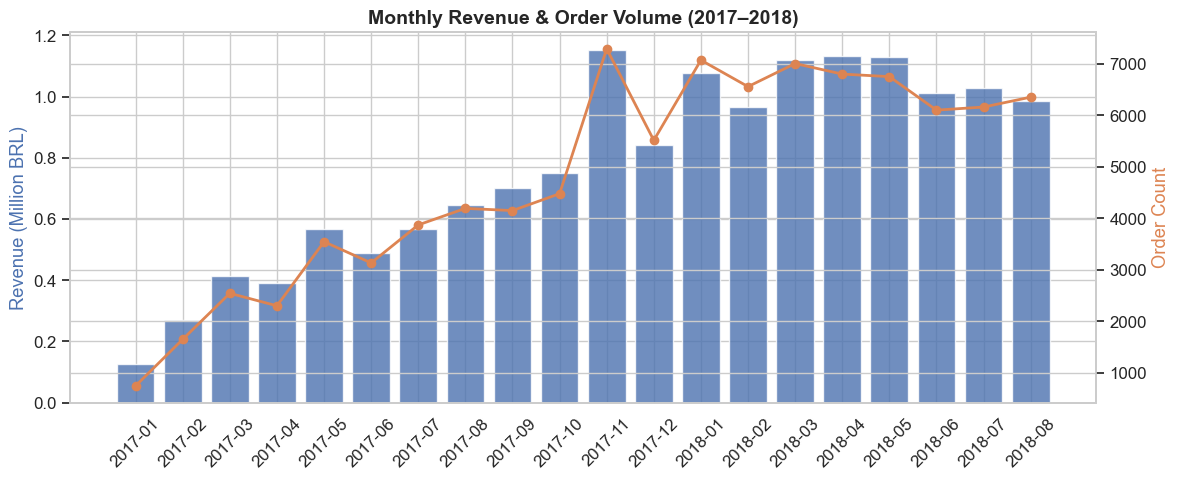

In [3]:
# --- Chart 1: Monthly Revenue & Order Volume (dual axis) ---
monthly = order_level.groupby("purchase_month").agg(
    revenue=("total_payment", "sum"),
    orders=("order_id", "count"),
).reset_index()
monthly = monthly[monthly["purchase_month"] >= "2017-01"]  # drop partial 2016

fig, ax1 = plt.subplots()
ax1.bar(monthly["purchase_month"], monthly["revenue"] / 1e6, color="#4C72B0", alpha=0.8, label="Revenue (M BRL)")
ax1.set_ylabel("Revenue (Million BRL)", color="#4C72B0")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["purchase_month"], monthly["orders"], color="#DD8452", marker="o", linewidth=2, label="Orders")
ax2.set_ylabel("Order Count", color="#DD8452")

plt.title("Monthly Revenue & Order Volume (2017–2018)")
fig.tight_layout()
plt.show()

**Insight 1 — Revenue and orders follow a strong upward trajectory with a sharp Nov 2017 spike.**

Revenue nearly doubled from Jan 2017 (~0.5M BRL) to Nov 2017 (~1.1M BRL), coinciding with Black Friday season. The platform is in a growth phase, but the heavy reliance on seasonal spikes means Olist needs to invest in non-seasonal demand generation (e.g., loyalty programmes, category promotions in low months like Feb–Mar) to smooth revenue.

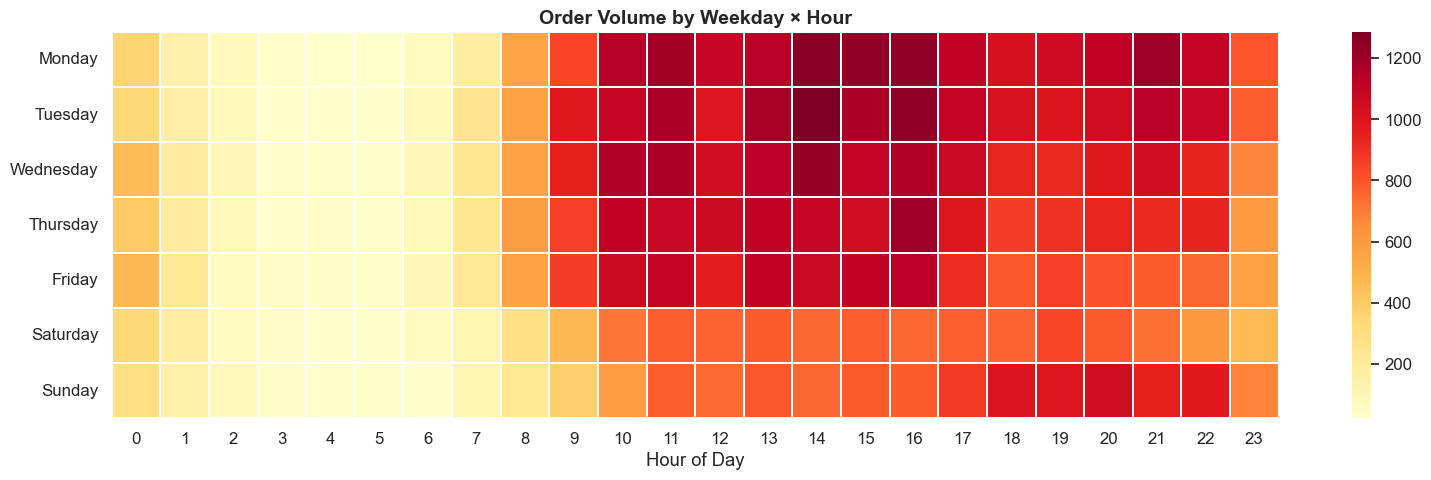

In [4]:
# --- Chart 2: Purchase Weekday & Hour Heatmap ---
df["weekday"] = df["order_purchase_timestamp"].dt.day_name()
df["hour"] = df["order_purchase_timestamp"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_wh = df.groupby(["weekday", "hour"]).size().unstack(fill_value=0).reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_wh, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
ax.set_title("Order Volume by Weekday × Hour")
plt.tight_layout()
plt.show()

**Insight 2 — Peak purchasing happens on weekdays 10am–4pm; weekends are dead zones.**

Monday through Friday dominate, with Tuesday and Wednesday showing the highest density. Weekend volume drops ~40%. This suggests B2B or office-hour browsing behaviour — Olist should schedule promotional emails, flash sales, and push notifications during weekday afternoons to maximise conversion, and use weekends for brand awareness campaigns rather than direct sales pushes.

---
# 2. Customer Geography

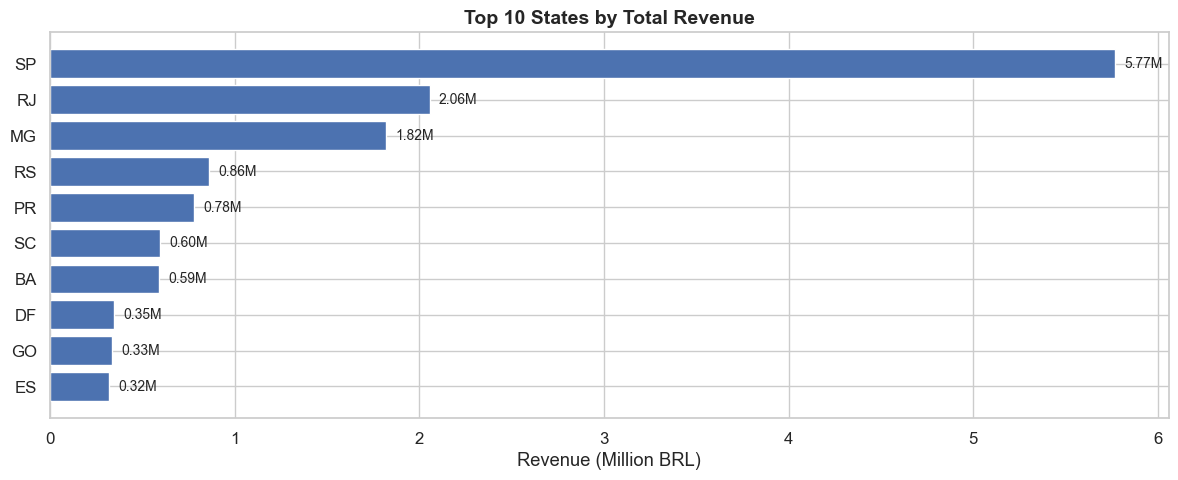

In [5]:
# --- Chart 3: Top 10 States by Revenue ---
state_rev = order_level.groupby("customer_state").agg(
    revenue=("total_payment", "sum"),
    orders=("order_id", "count"),
    avg_review=("review_score", "mean"),
).sort_values("revenue", ascending=False).head(10).reset_index()

fig, ax = plt.subplots()
bars = ax.barh(state_rev["customer_state"][::-1], state_rev["revenue"][::-1] / 1e6, color="#4C72B0")
ax.set_xlabel("Revenue (Million BRL)")
ax.set_title("Top 10 States by Total Revenue")
for bar, val in zip(bars, state_rev["revenue"][::-1] / 1e6):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.2f}M", va="center", fontsize=10)
plt.tight_layout()
plt.show()

**Insight 3 — SP alone accounts for ~40% of total revenue; the top 3 states (SP, RJ, MG) dominate.**

São Paulo, Rio de Janeiro, and Minas Gerais together represent the bulk of the business. This concentration creates risk — a logistics disruption in the Southeast directly hits the majority of revenue. Olist should actively grow the Northeast and South markets through targeted seller recruitment and regional delivery partnerships to diversify.

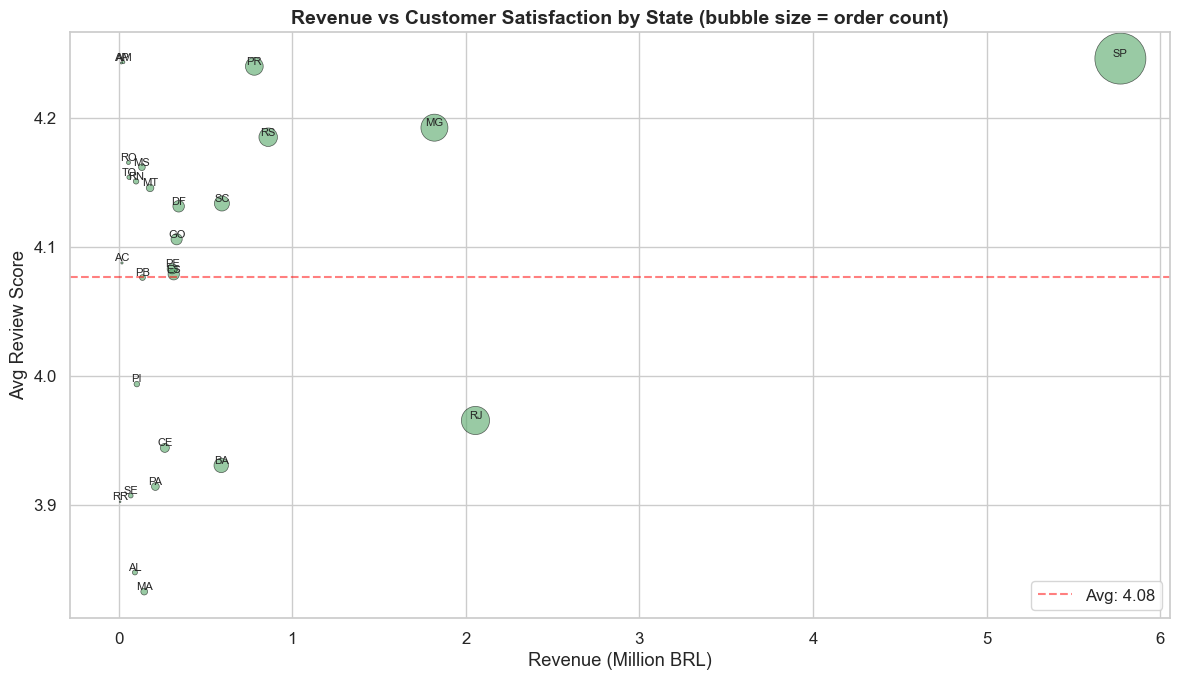

In [6]:
# --- Chart 4: Revenue vs Avg Review Score by State (bubble chart) ---
state_all = order_level.groupby("customer_state").agg(
    revenue=("total_payment", "sum"),
    orders=("order_id", "count"),
    avg_review=("review_score", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    state_all["revenue"] / 1e6,
    state_all["avg_review"],
    s=state_all["orders"] / 30,
    alpha=0.6, edgecolors="black", linewidth=0.5, c="#55A868",
)
for _, row in state_all.iterrows():
    ax.annotate(row["customer_state"], (row["revenue"] / 1e6, row["avg_review"]), fontsize=8, ha="center", va="bottom")

ax.set_xlabel("Revenue (Million BRL)")
ax.set_ylabel("Avg Review Score")
ax.set_title("Revenue vs Customer Satisfaction by State (bubble size = order count)")
ax.axhline(y=state_all["avg_review"].mean(), color="red", linestyle="--", alpha=0.5, label=f'Avg: {state_all["avg_review"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

**Insight 4 — High-revenue states don't always have high satisfaction; some small states outperform on CSAT.**

States like SP and RJ generate massive revenue but sit near or below the average review line. Meanwhile, smaller states (e.g., AC, RO) show higher satisfaction despite low volume. This suggests that customer experience in the dominant markets is under pressure — possibly from delivery delays or seller quality issues that come with scale. Olist should investigate whether the Southeast's logistics capacity is keeping up with demand.

---
# 3. Product Category Performance

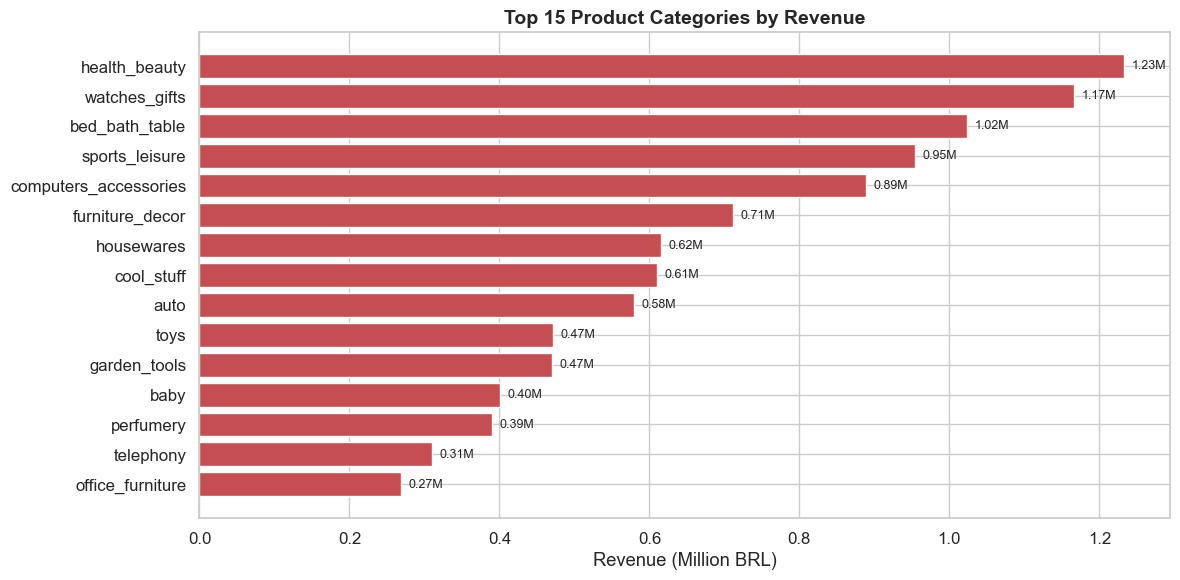

In [7]:
# --- Chart 5: Top 15 Categories by Revenue ---
cat_rev = df.groupby("product_category").agg(
    revenue=("price", "sum"),
    items=("price", "count"),
    avg_price=("price", "mean"),
).sort_values("revenue", ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_rev["product_category"][::-1], cat_rev["revenue"][::-1] / 1e6, color="#C44E52")
ax.set_xlabel("Revenue (Million BRL)")
ax.set_title("Top 15 Product Categories by Revenue")
for bar, val in zip(bars, cat_rev["revenue"][::-1] / 1e6):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Insight 5 — Health/beauty, watches, and bed/bath/table are the revenue engines, but their unit economics differ.**

Health & beauty leads on volume, while watches & gifts has a much higher average price point. Olist should segment its category strategy: grow volume in high-frequency categories (beauty, housewares) through subscriptions or bundles, and protect margins in high-ticket categories (watches, computers) through premium seller vetting and fraud prevention.

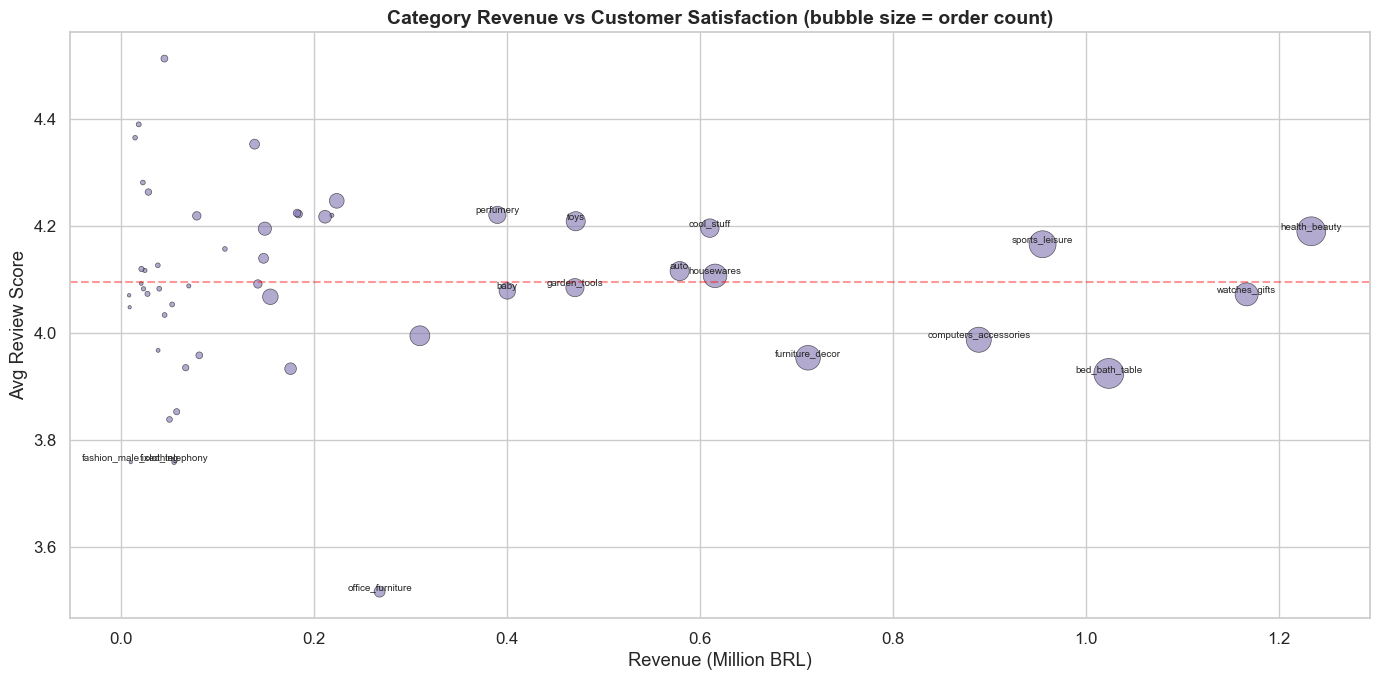

In [8]:
# --- Chart 6: Category Revenue vs Avg Review Score ---
cat_perf = df.groupby("product_category").agg(
    revenue=("price", "sum"),
    avg_review=("review_score", "mean"),
    order_count=("order_id", "nunique"),
).reset_index()
cat_perf = cat_perf[cat_perf["order_count"] >= 100]  # filter out tiny categories

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(
    cat_perf["revenue"] / 1e6, cat_perf["avg_review"],
    s=cat_perf["order_count"] / 20, alpha=0.6,
    edgecolors="black", linewidth=0.5, c="#8172B2",
)
for _, row in cat_perf.iterrows():
    if row["revenue"] > cat_perf["revenue"].quantile(0.75) or row["avg_review"] < 3.8:
        ax.annotate(row["product_category"], (row["revenue"] / 1e6, row["avg_review"]), fontsize=7, ha="center", va="bottom")

ax.set_xlabel("Revenue (Million BRL)")
ax.set_ylabel("Avg Review Score")
ax.set_title("Category Revenue vs Customer Satisfaction (bubble size = order count)")
ax.axhline(y=cat_perf["avg_review"].mean(), color="red", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Insight 6 — Several high-revenue categories have below-average satisfaction — a silent churn risk.**

Categories like computers_accessories and furniture_decor generate significant revenue but sit below the mean review line. These are likely categories with complex logistics (heavy, fragile items) where delivery quality directly hurts satisfaction. Olist should create a "premium logistics" tier for these categories — special packaging, priority carrier assignment — to protect revenue from review-driven churn.

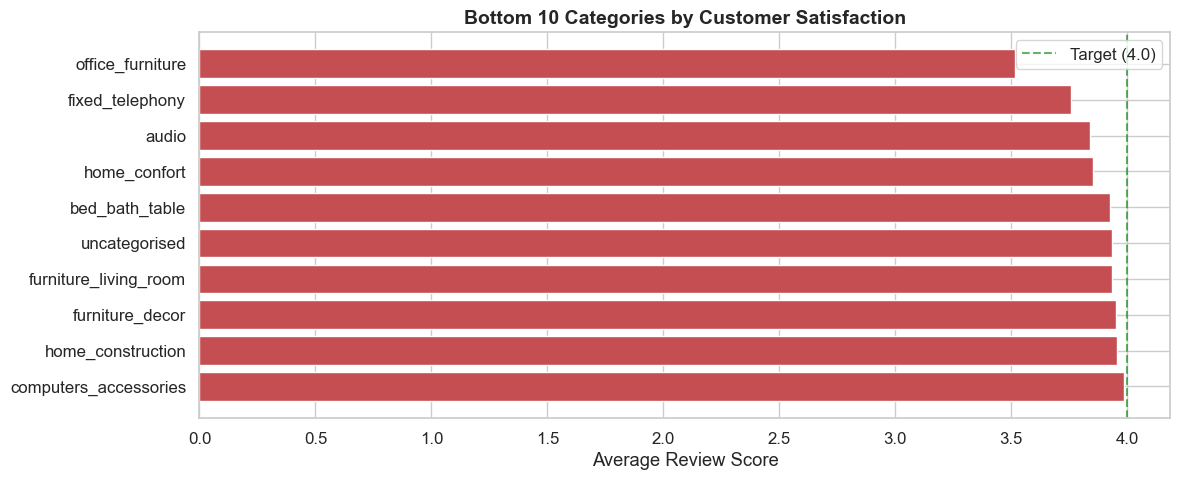

In [9]:
# --- Chart 7: Bottom 10 Categories by Review Score ---
cat_review = df.groupby("product_category").agg(
    avg_review=("review_score", "mean"),
    order_count=("order_id", "nunique"),
).query("order_count >= 200").sort_values("avg_review").head(10).reset_index()

fig, ax = plt.subplots()
ax.barh(cat_review["product_category"][::-1], cat_review["avg_review"][::-1], color="#C44E52")
ax.set_xlabel("Average Review Score")
ax.axvline(x=4.0, color="green", linestyle="--", alpha=0.6, label="Target (4.0)")
ax.set_title("Bottom 10 Categories by Customer Satisfaction")
ax.legend()
plt.tight_layout()
plt.show()

**Insight 7 — Office furniture, computers, and home appliances are satisfaction laggards.**

These categories share a trait: bulky, expensive items where delivery expectations are high. The gap between customer expectation and actual delivery experience is widest here. Olist should audit the seller and logistics chain for these specific categories — introducing seller rating minimums and carrier SLA enforcement could recover significant review score points.

---
# 4. Delivery & Customer Satisfaction

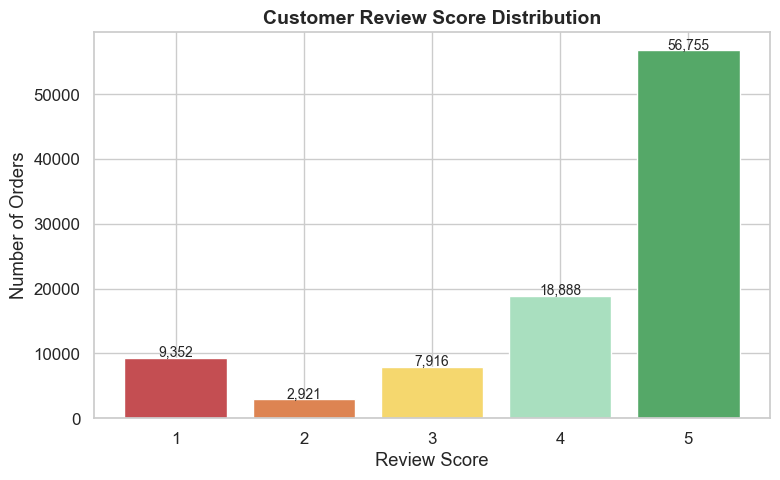

In [10]:
# --- Chart 8: Review Score Distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
review_counts = order_level["review_score"].value_counts().sort_index()
ax.bar(review_counts.index, review_counts.values, color=["#C44E52", "#DD8452", "#F5D76E", "#A9DFBF", "#55A868"])
ax.set_xlabel("Review Score")
ax.set_ylabel("Number of Orders")
ax.set_title("Customer Review Score Distribution")
for i, v in enumerate(review_counts.values):
    ax.text(review_counts.index[i], v + 200, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Insight 8 — Satisfaction is bimodal: most customers are happy (score 5), but a significant angry minority (score 1) needs attention.**

Score 5 dominates, but score 1 is the second-largest bucket — there's very little middle ground (scores 2-3 are relatively small). This "love it or hate it" pattern means Olist has two distinct problems: maintaining the excellence for satisfied customers, and root-causing the failures for the angry ones. Score-1 orders should be flagged for immediate follow-up and operational review.

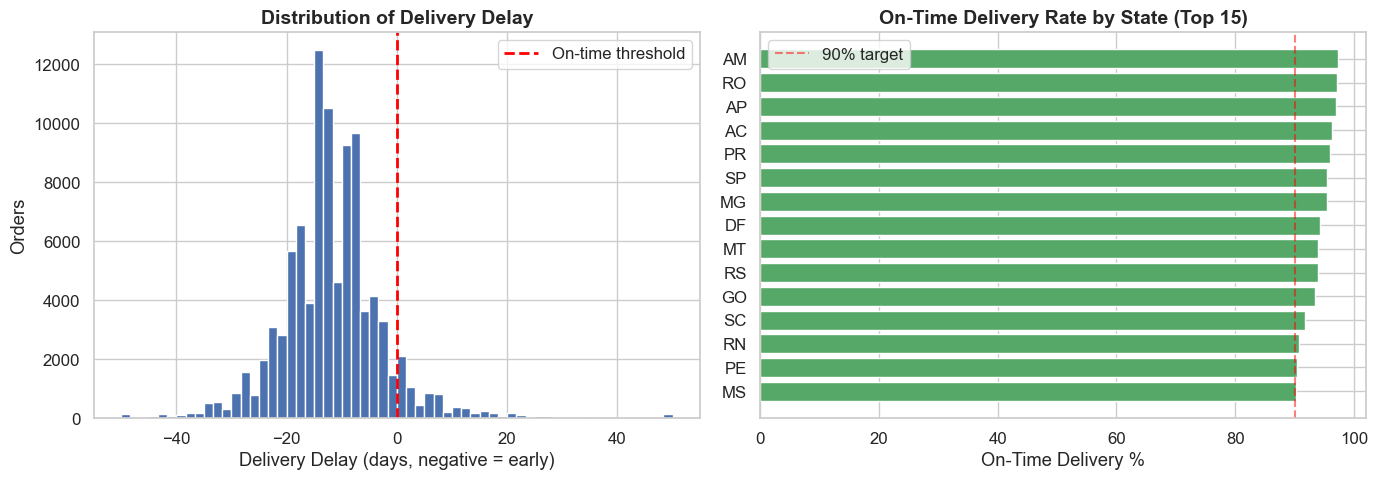

In [11]:
# --- Chart 9: Delivery Delay Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of delay days (capped for visibility)
delay_data = order_level["delivery_delay_days"].dropna()
delay_capped = delay_data.clip(-50, 50)
axes[0].hist(delay_capped, bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2, label="On-time threshold")
axes[0].set_xlabel("Delivery Delay (days, negative = early)")
axes[0].set_ylabel("Orders")
axes[0].set_title("Distribution of Delivery Delay")
axes[0].legend()

# Right: on-time % by state (top 15)
state_ot = order_level.groupby("customer_state")["is_on_time"].mean().sort_values().tail(15)
colors = ["#55A868" if v >= 0.9 else "#DD8452" if v >= 0.85 else "#C44E52" for v in state_ot.values]
axes[1].barh(state_ot.index, state_ot.values * 100, color=colors)
axes[1].set_xlabel("On-Time Delivery %")
axes[1].set_title("On-Time Delivery Rate by State (Top 15)")
axes[1].axvline(x=90, color="red", linestyle="--", alpha=0.5, label="90% target")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight 9 — Most orders arrive early, but late deliveries cluster heavily at 1–15 days past estimate.**

The peak of the delay distribution sits at -10 to -5 days (most orders arrive well before estimate). However, there's a long right tail of late deliveries. Olist is over-promising on delivery estimates — tightening estimated delivery windows would set more accurate expectations and reduce the perception of lateness even if actual delivery doesn't change.

/var/folders/86/5wf389g13x99z87yycx6gj5r0000gn/T/ipykernel_10620/449765659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="review_score", y="delivery_delay_days", ax=ax, palette="RdYlGn")


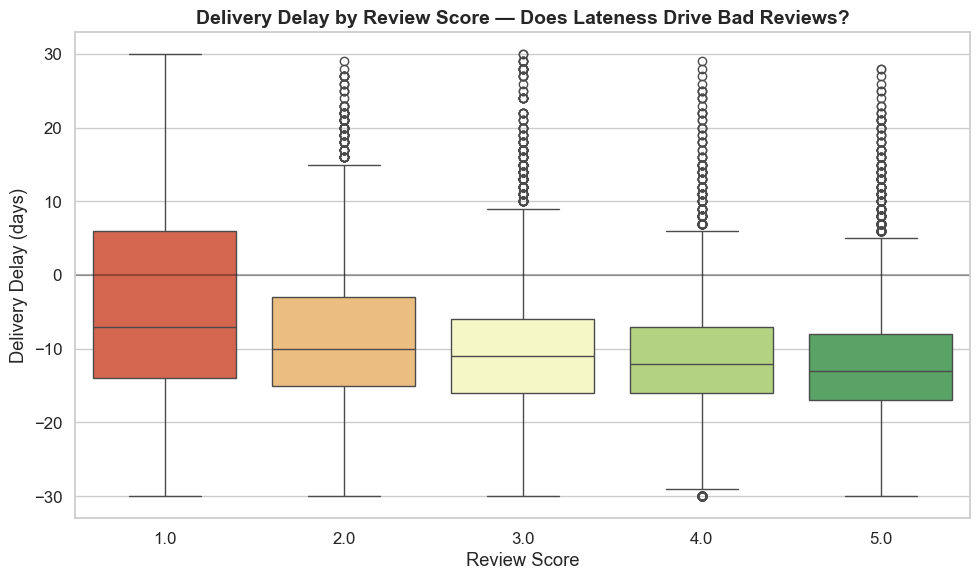

In [12]:
# --- Chart 10: Review Score vs Delivery Delay (box plot) ---
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = order_level[order_level["delivery_delay_days"].between(-30, 30)]
sns.boxplot(data=plot_data, x="review_score", y="delivery_delay_days", ax=ax, palette="RdYlGn")
ax.set_xlabel("Review Score")
ax.set_ylabel("Delivery Delay (days)")
ax.set_title("Delivery Delay by Review Score — Does Lateness Drive Bad Reviews?")
ax.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight 10 — Late delivery is strongly associated with score-1 reviews; even slightly late orders see satisfaction drop.**

Score-5 orders have a median delay well below zero (early delivery). Score-1 orders have a median delay above zero. The relationship is clear: delivery timeliness is one of the strongest levers on customer satisfaction. Reducing late deliveries by even 2-3 days could shift a significant portion of score-1 and score-2 reviews upward, directly improving the CSAT KPI.

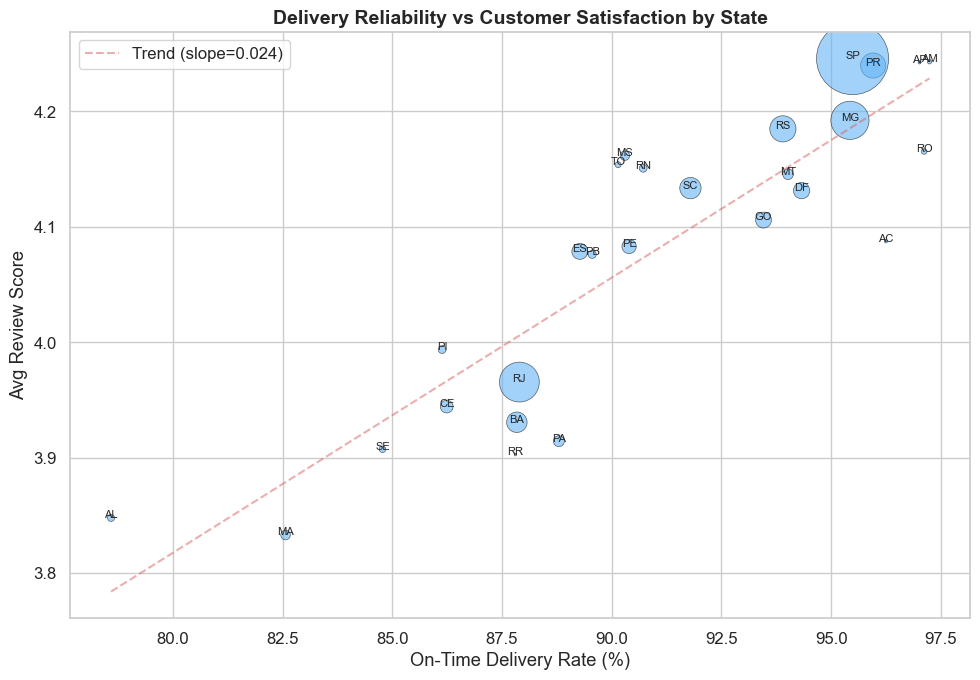

In [13]:
# --- Chart 11: On-Time Rate vs Avg Review Score by State ---
state_metrics = order_level.groupby("customer_state").agg(
    on_time_rate=("is_on_time", "mean"),
    avg_review=("review_score", "mean"),
    orders=("order_id", "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    state_metrics["on_time_rate"] * 100,
    state_metrics["avg_review"],
    s=state_metrics["orders"] / 15,
    alpha=0.6, edgecolors="black", linewidth=0.5, c="#64B5F6",
)
for _, row in state_metrics.iterrows():
    ax.annotate(row["customer_state"], (row["on_time_rate"] * 100, row["avg_review"]), fontsize=8, ha="center")

# Trend line
z = np.polyfit(state_metrics["on_time_rate"] * 100, state_metrics["avg_review"], 1)
p = np.poly1d(z)
x_line = np.linspace(state_metrics["on_time_rate"].min() * 100, state_metrics["on_time_rate"].max() * 100, 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"Trend (slope={z[0]:.3f})")

ax.set_xlabel("On-Time Delivery Rate (%)")
ax.set_ylabel("Avg Review Score")
ax.set_title("Delivery Reliability vs Customer Satisfaction by State")
ax.legend()
plt.tight_layout()
plt.show()

**Insight 11 — States with better on-time delivery have higher satisfaction — the correlation is visible and actionable.**

The positive trend line shows that every percentage point improvement in on-time delivery maps to higher review scores. States in the lower-left quadrant (low on-time, low satisfaction) are the highest-priority targets for logistics investment. Olist should rank carrier partners by state-level performance and re-allocate volume to the best performers in each region.

---
# 5. Payment Behaviour & Pricing

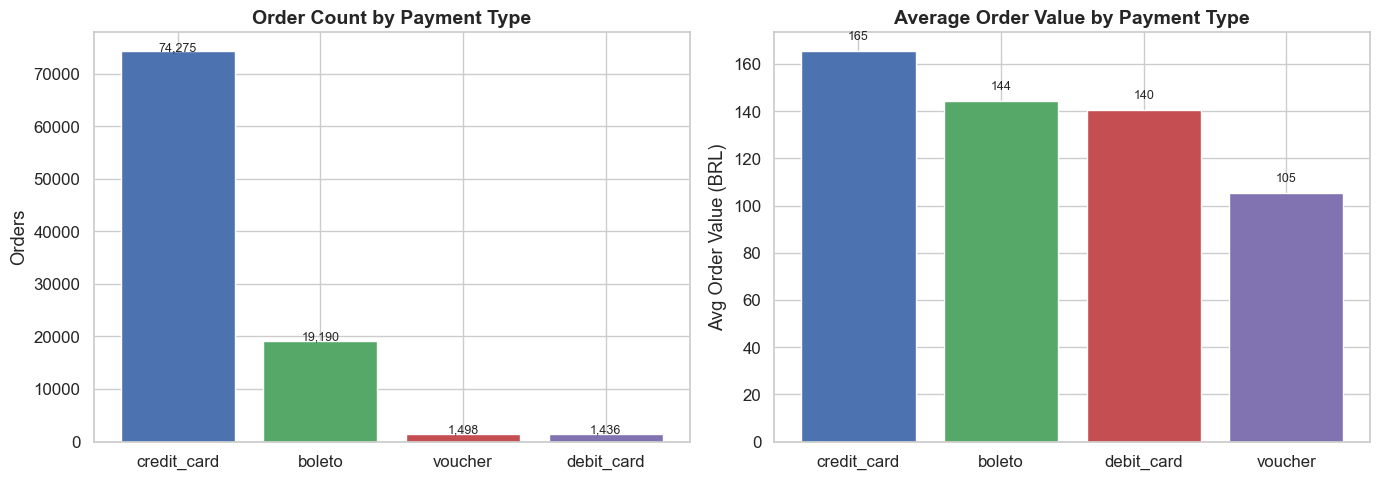

In [14]:
# --- Chart 12: Payment Type Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: payment type by count
pay_counts = order_level["primary_payment_type"].value_counts()
axes[0].bar(pay_counts.index, pay_counts.values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"])
axes[0].set_ylabel("Orders")
axes[0].set_title("Order Count by Payment Type")
for i, v in enumerate(pay_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

# Right: avg order value by payment type
pay_aov = order_level.groupby("primary_payment_type")["total_payment"].mean().sort_values(ascending=False)
axes[1].bar(pay_aov.index, pay_aov.values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"])
axes[1].set_ylabel("Avg Order Value (BRL)")
axes[1].set_title("Average Order Value by Payment Type")
for i, v in enumerate(pay_aov.values):
    axes[1].text(i, v + 5, f"{v:.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Insight 12 — Credit card dominates in volume, but boleto and debit card users spend differently.**

Credit card accounts for ~75% of orders and has the highest AOV (~BRL 170), boosted by instalment purchasing. Boleto (a Brazilian cash-payment method) has lower AOV (~BRL 140) but represents a large underserved segment. Olist could increase boleto AOV by offering targeted discounts for adding items to boleto orders, or by introducing gift-card top-ups for boleto users.

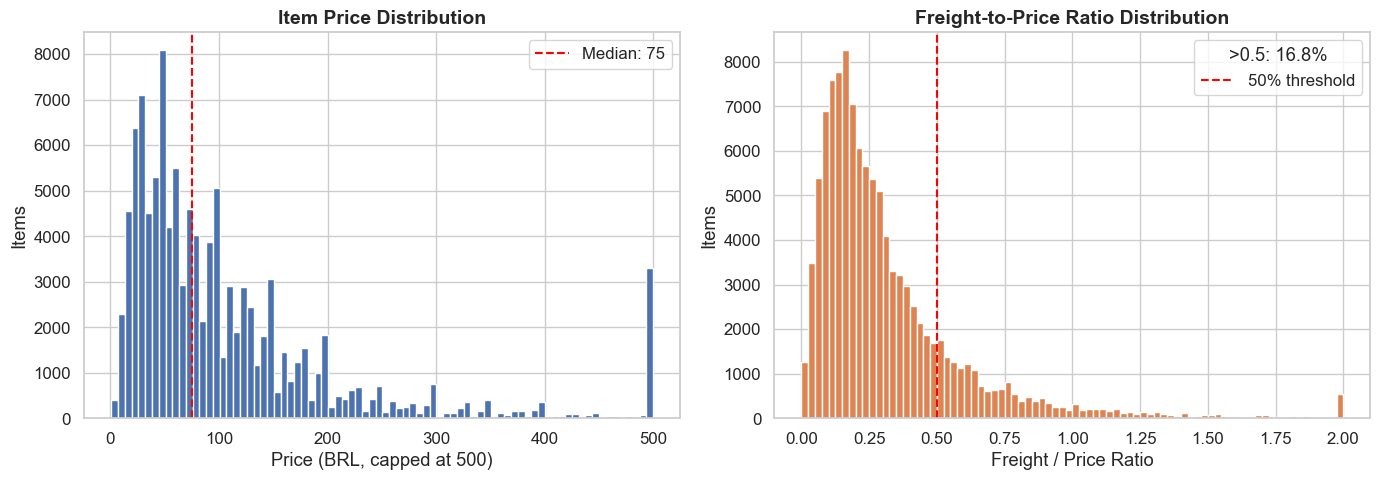

In [15]:
# --- Chart 13: Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"].clip(upper=500), bins=80, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Price (BRL, capped at 500)")
axes[0].set_ylabel("Items")
axes[0].set_title("Item Price Distribution")
axes[0].axvline(x=df["price"].median(), color="red", linestyle="--", label=f'Median: {df["price"].median():.0f}')
axes[0].legend()

# Right: freight ratio distribution
fr = df["freight_ratio"].dropna().clip(upper=2)
axes[1].hist(fr, bins=80, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("Freight / Price Ratio")
axes[1].set_ylabel("Items")
axes[1].set_title("Freight-to-Price Ratio Distribution")
axes[1].axvline(x=0.5, color="red", linestyle="--", label="50% threshold")
high_freight_pct = (df["freight_ratio"] > 0.5).mean()
axes[1].legend(title=f">0.5: {high_freight_pct:.1%}")

plt.tight_layout()
plt.show()

**Insight 13 — Most items are low-priced; freight cost exceeds 50% of item price for ~15% of orders.**

The median price is ~BRL 75-85, with a heavy right tail. The freight ratio distribution shows that for a significant portion of orders, shipping costs are disproportionately high relative to the item price. These high-freight-ratio orders are likely low-priced items with standard shipping — Olist should introduce minimum order thresholds for free shipping or bundle low-price items to improve perceived value and reduce sticker shock at checkout.

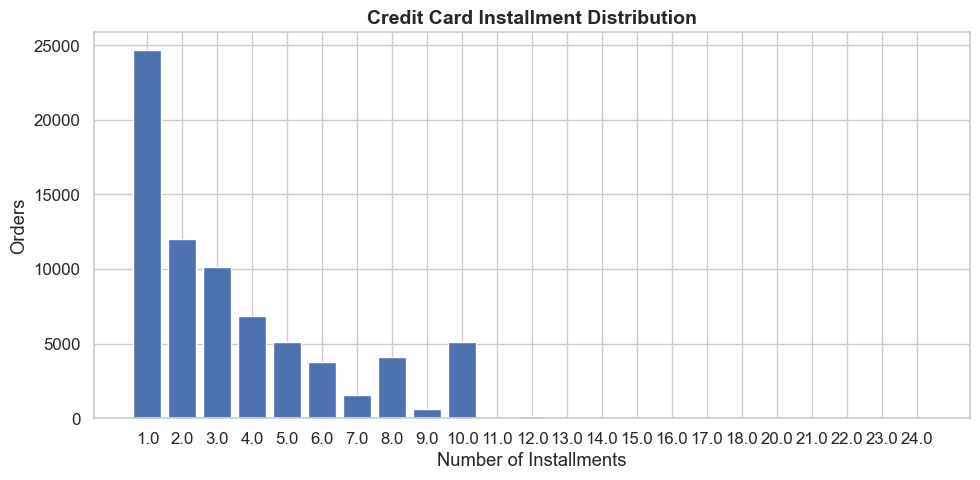

Single payment (1x): 24,658 orders (33.2%)
3+ installments:     37,593 orders (50.6%)
8+ installments:     10,185 orders (13.7%)


In [16]:
# --- Chart 14: Instalment Distribution for Credit Card Users ---
cc_orders = order_level[order_level["primary_payment_type"] == "credit_card"]
inst = cc_orders["max_installments"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(inst.index.astype(str), inst.values, color="#4C72B0")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Orders")
ax.set_title("Credit Card Installment Distribution")
plt.tight_layout()
plt.show()

print(f"Single payment (1x): {(cc_orders['max_installments'] == 1).sum():,} orders ({(cc_orders['max_installments'] == 1).mean():.1%})")
print(f"3+ installments:     {(cc_orders['max_installments'] >= 3).sum():,} orders ({(cc_orders['max_installments'] >= 3).mean():.1%})")
print(f"8+ installments:     {(cc_orders['max_installments'] >= 8).sum():,} orders ({(cc_orders['max_installments'] >= 8).mean():.1%})")

**Insight 14 — Over 50% of credit card users pay in instalments of 3 or more; heavy instalment use signals price sensitivity.**

A significant share of credit card orders use 4-10 instalments, indicating that customers are stretching payments. Olist can leverage this by offering targeted promotions on instalment-heavy categories (e.g., electronics, furniture) and partnering with card issuers for zero-interest instalment campaigns that increase conversion without reducing average order value.

---
# 6. Outlier Detection & Data Quality

/var/folders/86/5wf389g13x99z87yycx6gj5r0000gn/T/ipykernel_10620/3978966662.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_subset, y="product_category", x="price", ax=axes[0], palette="Set2")


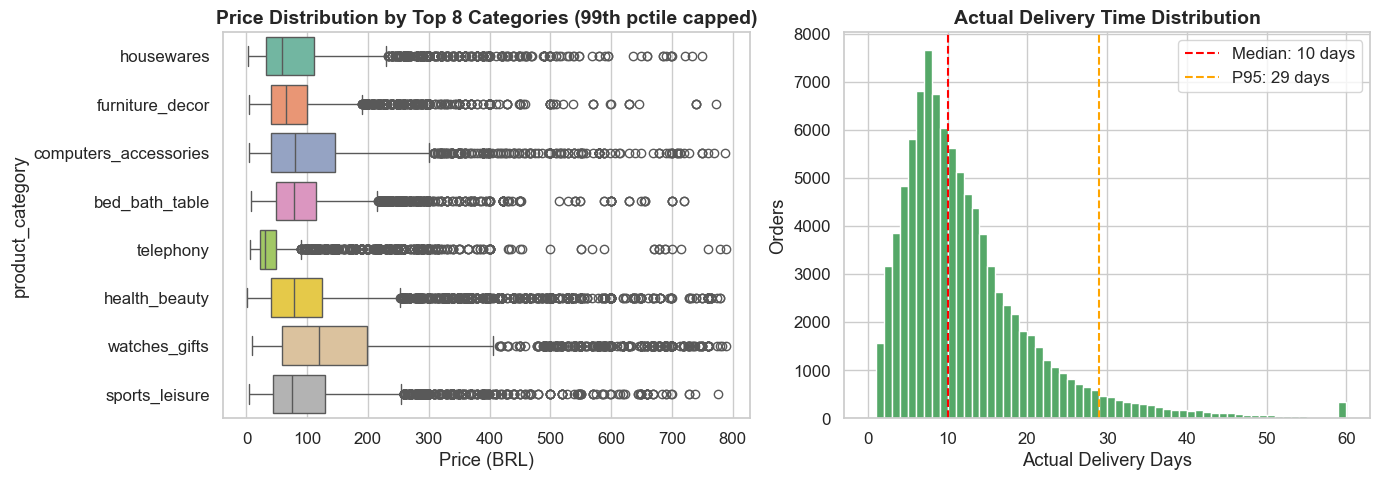

In [17]:
# --- Chart 15: Outlier analysis — Price & Delivery Days ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price boxplot by top categories
top_cats = df["product_category"].value_counts().head(8).index
price_subset = df[df["product_category"].isin(top_cats)]
price_subset = price_subset[price_subset["price"] < price_subset["price"].quantile(0.99)]  # trim extreme outliers for viz
sns.boxplot(data=price_subset, y="product_category", x="price", ax=axes[0], palette="Set2")
axes[0].set_title("Price Distribution by Top 8 Categories (99th pctile capped)")
axes[0].set_xlabel("Price (BRL)")

# Actual delivery days distribution
del_days = order_level["actual_delivery_days"].dropna()
del_days_capped = del_days.clip(upper=60)
axes[1].hist(del_days_capped, bins=60, color="#55A868", edgecolor="white")
axes[1].axvline(x=del_days.median(), color="red", linestyle="--", label=f'Median: {del_days.median():.0f} days')
axes[1].axvline(x=del_days.quantile(0.95), color="orange", linestyle="--", label=f'P95: {del_days.quantile(0.95):.0f} days')
axes[1].set_xlabel("Actual Delivery Days")
axes[1].set_ylabel("Orders")
axes[1].set_title("Actual Delivery Time Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight 15 — Watches and computers have the widest price spread; 95% of orders deliver within ~24 days.**

Category price variance is enormous — watches & gifts and computers have long right tails that will skew averages. For delivery, the median is ~10 days but the 95th percentile is ~24 days, meaning 5% of orders take disproportionately long. Olist should set a delivery SLA cap (e.g., 20 days max for metro areas) and auto-escalate orders approaching the limit for proactive customer communication.

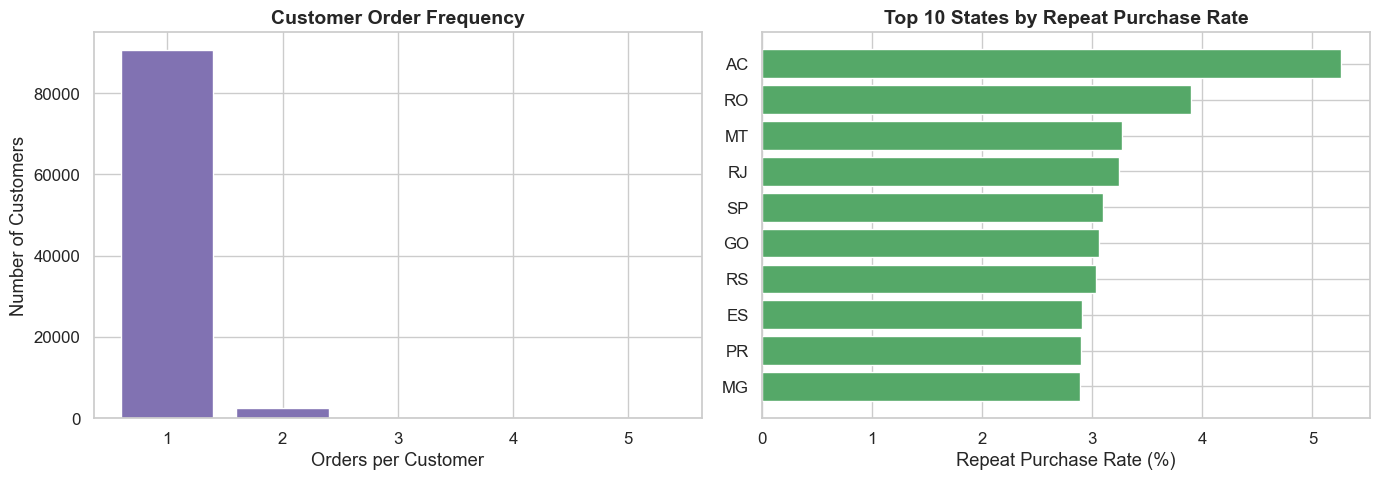


Overall repeat purchase rate: 3.0%
Customers with 1 order:     90,557 (97.0%)
Customers with 2+ orders:    2,801 (3.0%


In [18]:
# --- Chart 16: Repeat Purchase Analysis ---
cust_order_count = order_level.groupby("customer_unique_id").size()
repeat_rate = (cust_order_count > 1).mean()
repeat_dist = cust_order_count.value_counts().sort_index().head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(repeat_dist.index.astype(str), repeat_dist.values, color="#8172B2")
axes[0].set_xlabel("Orders per Customer")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Customer Order Frequency")

# Repeat rate by top states
state_cust = order_level.groupby(["customer_state", "customer_unique_id"]).size().reset_index(name="orders")
state_repeat_rate = state_cust.groupby("customer_state").apply(
    lambda g: (g["orders"] > 1).mean()
).sort_values(ascending=False).head(10)

axes[1].barh(state_repeat_rate.index[::-1], state_repeat_rate.values[::-1] * 100, color="#55A868")
axes[1].set_xlabel("Repeat Purchase Rate (%)")
axes[1].set_title("Top 10 States by Repeat Purchase Rate")

plt.tight_layout()
plt.show()

print(f"\nOverall repeat purchase rate: {repeat_rate:.1%}")
print(f"Customers with 1 order:     {(cust_order_count == 1).sum():,} ({(cust_order_count == 1).mean():.1%})")
print(f"Customers with 2+ orders:    {(cust_order_count >= 2).sum():,} ({(cust_order_count >= 2).mean():.1%}")

**Insight 16 — Only ~3% of customers return; retention is the single biggest growth lever.**

The vast majority of customers place exactly one order. With a 97% one-and-done rate, Olist is effectively running an acquisition-only business with very high customer acquisition cost relative to lifetime value. A 2-3 percentage point increase in repeat purchase rate (through post-purchase follow-up emails, loyalty discounts, or personalised recommendations) could increase revenue by 15-20% without any new customer acquisition spend.

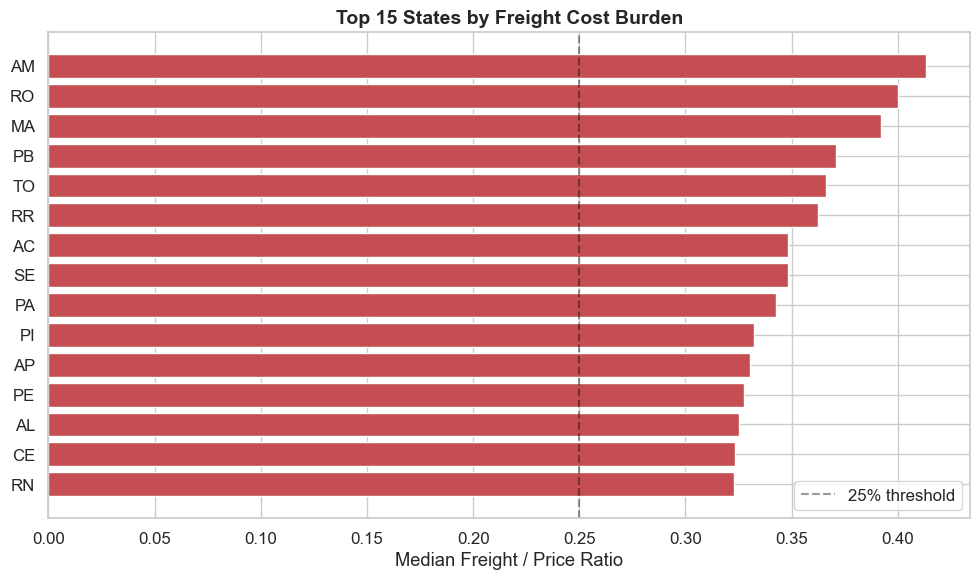

In [19]:
# --- Chart 17: Freight Ratio by State (where is shipping most expensive?) ---
state_freight = df.groupby("customer_state").agg(
    avg_freight_ratio=("freight_ratio", "median"),
    avg_freight_value=("freight_value", "mean"),
    orders=("order_id", "nunique"),
).sort_values("avg_freight_ratio", ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if v > 0.3 else "#DD8452" if v > 0.2 else "#55A868" for v in state_freight["avg_freight_ratio"]]
ax.barh(state_freight["customer_state"][::-1], state_freight["avg_freight_ratio"][::-1], color=colors[::-1])
ax.set_xlabel("Median Freight / Price Ratio")
ax.set_title("Top 15 States by Freight Cost Burden")
ax.axvline(x=0.25, color="black", linestyle="--", alpha=0.4, label="25% threshold")
ax.legend()
plt.tight_layout()
plt.show()

**Insight 17 — Remote Northern/Northeastern states bear disproportionately high freight costs.**

States like RR (Roraima), AP (Amapá), and AC (Acre) — all in Brazil's far North — have freight ratios nearly double the national average. This geographic penalty suppresses conversion and repeat purchase in those regions. Olist should negotiate regional carrier rates or establish forward-positioned warehouses in key Northern hubs (e.g., Manaus) to equalise shipping costs nationwide.

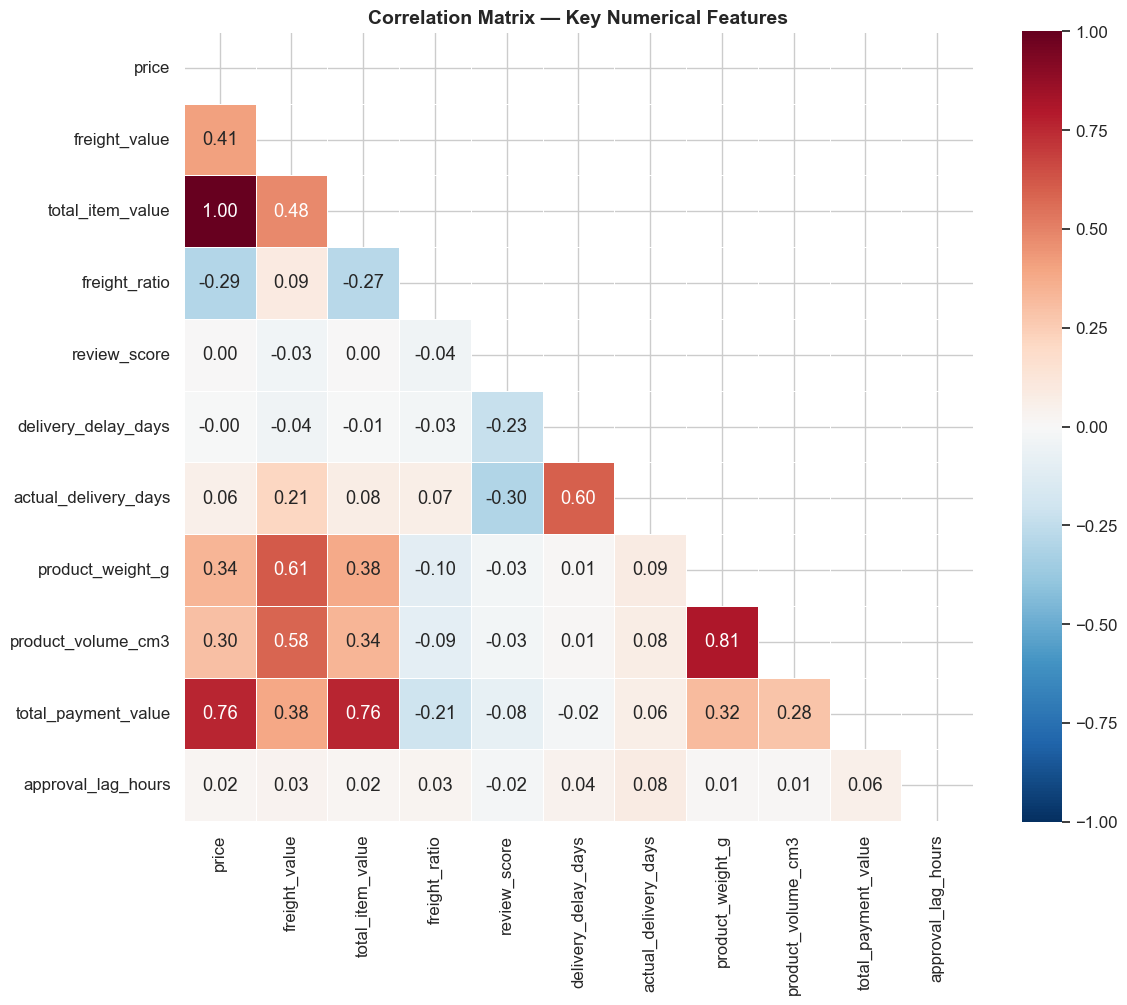

In [20]:
# --- Chart 18: Correlation Heatmap (numerical features) ---
numeric_cols = ["price", "freight_value", "total_item_value", "freight_ratio",
               "review_score", "delivery_delay_days", "actual_delivery_days",
               "product_weight_g", "product_volume_cm3", "total_payment_value",
               "approval_lag_hours"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Key Numerical Features")
plt.tight_layout()
plt.show()

**Insight 18 — Review score has the strongest negative correlation with delivery delay; price and freight are naturally linked to weight/volume.**

The correlation matrix confirms what the visualisations suggested: `delivery_delay_days` and `review_score` are negatively correlated — as delay increases, satisfaction drops. Meanwhile, `price` and `freight_value` correlate with `product_weight_g` and `product_volume_cm3`, confirming that heavier/bulkier items cost more to ship. These relationships will be formally tested with hypothesis testing in notebook 04.

---
# EDA Summary — Key Takeaways for Stakeholders

| # | Insight | Business Action |
|---|---|---|
| 1 | Revenue spiked in Nov 2017 (Black Friday); growth is strong but seasonal | Build non-seasonal demand engines |
| 2 | Peak orders weekday 10am–4pm; weekends are quiet | Schedule promotions for weekday afternoons |
| 3 | SP/RJ/MG dominate revenue — geographic concentration risk | Invest in Northeast/South market development |
| 4 | High-revenue states don't always have high satisfaction | Investigate Southeast logistics capacity |
| 5 | Health/beauty leads volume; watches lead price | Segment category strategy by volume vs margin |
| 6 | High-revenue categories (furniture, computers) have below-average satisfaction | Premium logistics tier for bulky/fragile items |
| 7 | Office furniture, computers, appliances are satisfaction laggards | Audit seller/carrier quality in those categories |
| 8 | Review scores are bimodal — love it or hate it | Flag score-1 orders for operational review |
| 9 | Most orders arrive early; late tail clusters at 1-15 days | Tighten delivery estimate windows |
| 10 | Late delivery directly drives score-1 reviews | Every 2-3 day reduction shifts reviews upward |
| 11 | On-time delivery rate positively correlates with satisfaction by state | Rank carriers by state; re-allocate to best performers |
| 12 | Credit card dominates; boleto users spend less | Targeted bundles to increase boleto AOV |
| 13 | 15% of orders have freight > 50% of item price | Introduce minimum order thresholds for free shipping |
| 14 | 50%+ of credit card users pay in 3+ installments | Partner with card issuers for zero-interest campaigns |
| 15 | 95% of orders deliver within 24 days; outliers in price by category | Set 20-day delivery SLA for metro areas |
| 16 | Only 3% repeat purchase rate — massive retention gap | Post-purchase engagement and loyalty programme |
| 17 | Northern/Northeastern states pay 2x freight ratios | Regional carrier negotiations or forward warehouses |
| 18 | Delivery delay is the strongest numerical correlate of low reviews | Make delivery speed the #1 operations KPI |

**Next step**: `04_statistical_analysis.ipynb` — formal hypothesis testing, regression, and customer segmentation.